In [4]:
import numpy as np #linear algebra
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day24-standardization/Social_Network_Ads.csv')

In [6]:
df = df.iloc[:,2:]

In [7]:
df.sample(5)

,Age,EstimatedSalary,Purchased
357,41,72000,0
367,46,88000,1
186,20,82000,0
222,37,144000,1
118,40,59000,0


## Train Test Split

In [8]:
from sklearn.model_selection import  train_test_split
X_train , X_test , y_train , y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)
X_train.shape,X_test.shape

((280, 2), (120, 2))

# Standard Scaler

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit the scaler to train set , it will learn the parameters
scaler.fit(X_train)

#transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [18]:
X_train_scaled = pd.DataFrame(X_train_scaled , columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled , columns = X_test.columns)

In [19]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [20]:
np.round(X_train_scaled.describe() , 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


# Effect of Scaling

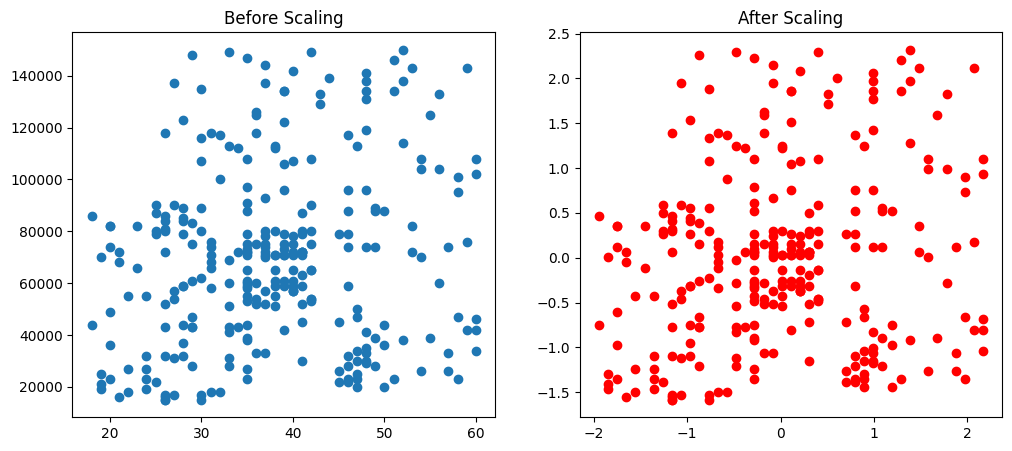

In [21]:
fig , (ax1 ,ax2) = plt.subplots(ncols=2 ,nrows=1, figsize=(12,5)) # displays both graphs in the same row

ax1.scatter(X_train['Age'] ,X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],color = 'red')
ax2.set_title("After Scaling")
plt.show()

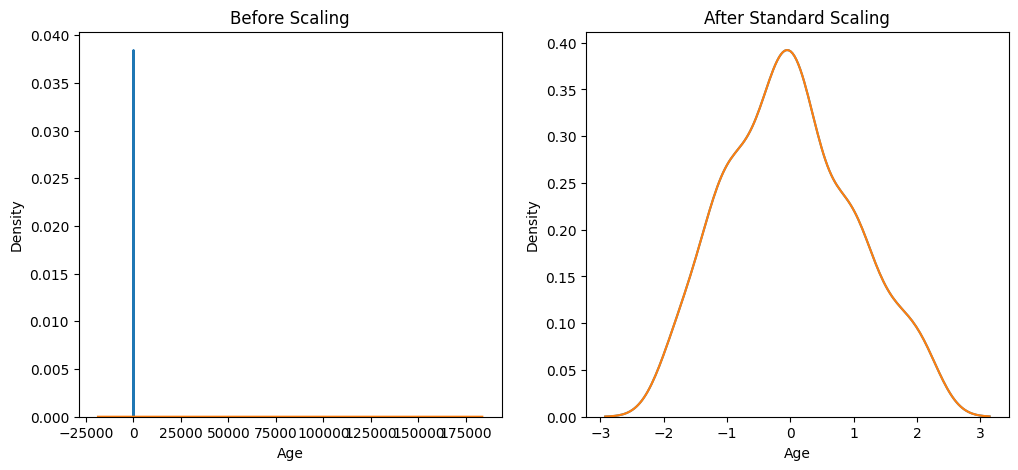

In [22]:
fig , (ax1 , ax2) = plt.subplots(ncols=2 , nrows=1, figsize=(12,5))
#kdeplot gives Probability Density Function (PDF)
#before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax = ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax = ax1)

#after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
plt.show()

# Comparison of Distributions

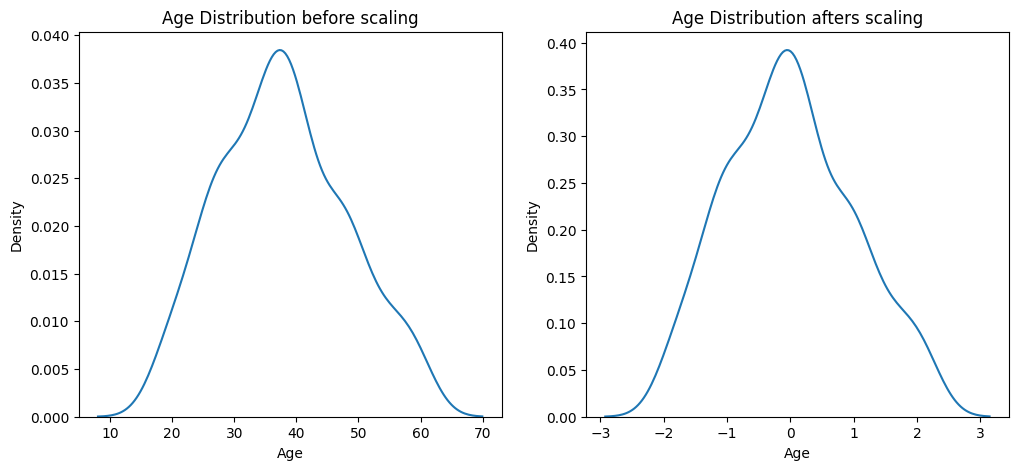

In [23]:
fig , (ax1 , ax2) = plt.subplots(ncols=2,figsize=(12,5))

#before scaling
ax1.set_title('Age Distribution before scaling')
sns.kdeplot(X_train['Age'],ax=ax1)

#after scaling
ax2.set_title('Age Distribution afters scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
plt.show()

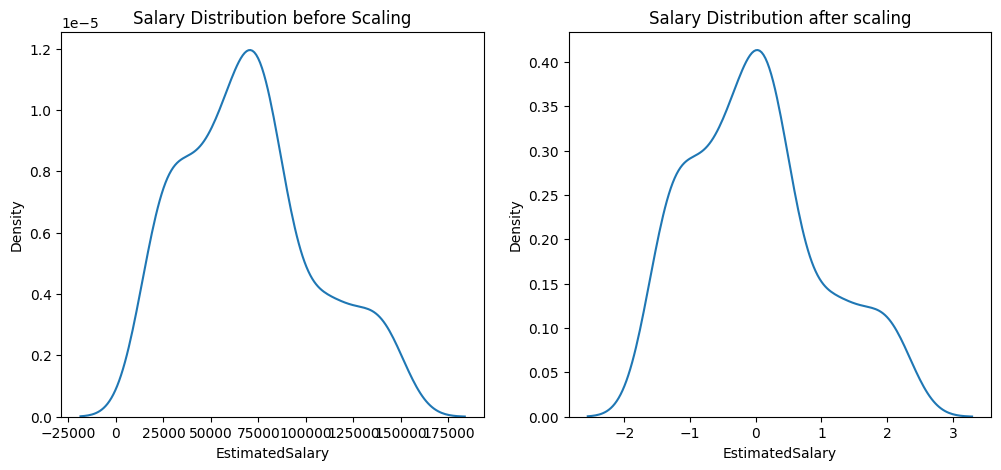

In [24]:
fig , (ax1,ax2) = plt.subplots(ncols=2 , figsize=(12,5))

#before scaling
ax1.set_title('Salary Distribution before Scaling')
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

#after scaling
ax2.set_title('Salary Distribution after scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)
plt.show()

# Why Scaling is important

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

In [29]:
lr = LogisticRegression(max_iter=1000)
lr_scaled = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

print("Without Scaling(0.65 ke kreeb):",
      accuracy_score(y_test, y_pred))

print("With Scaling(0.8 ke kreeb):",
      accuracy_score(y_test, y_pred_scaled))

Without Scaling(0.65 ke kreeb): 0.875
With Scaling(0.8 ke kreeb): 0.8666666666666667


# Effect of Outlier

In [86]:
new_rows = pd.DataFrame({
    'Age':[5,90,95],
    'EstimatedSalary':[1000,250000,350000],
    'Purchased':[0,1,1]
})

df = pd.concat([df, new_rows], ignore_index=True)

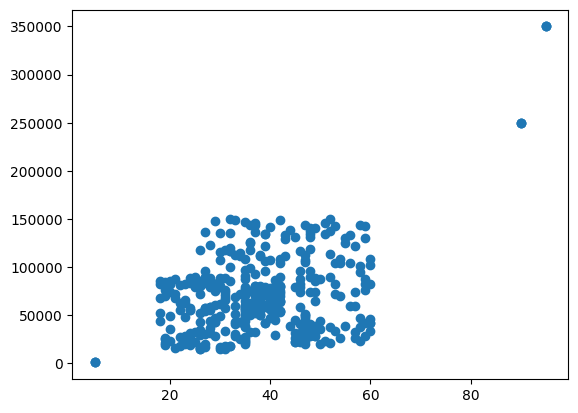

In [87]:

plt.scatter(df['Age'], df['EstimatedSalary'])

In [82]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((284, 2), (122, 2))

In [83]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [84]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

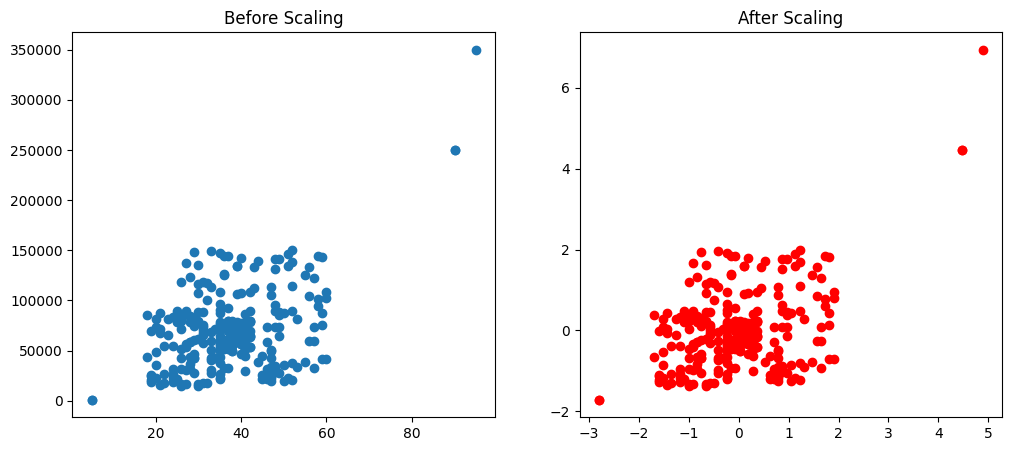

In [85]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

Therefore Outliers are needed to be handled seperately